
Linear → RMSE: 19.63, R²: 0.04

RandomForest → RMSE: 19.90, R²: 0.01

📊 Model Comparison Table:

          Model       RMSE        R2
0        Linear  19.629441  0.040877
1  RandomForest  19.903613  0.013897


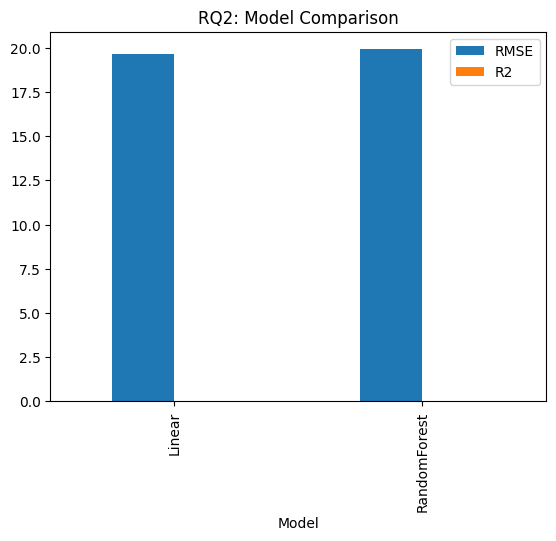

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load
df = pd.read_csv("/content/tracks.csv")
df = df.select_dtypes(include="number") # Select only numeric columns
df = df.fillna(df.median()) # Fill NaN values with the median of numeric columns

X = df.drop("popularity", axis=1)
y = df["popularity"]

X = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y)

models = {
    "Linear": LinearRegression(),
    "RandomForest": RandomForestRegressor()
}

results = []

for name, m in models.items():
    m.fit(X_train, y_train)
    pred = m.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    print(f"\n{name} → RMSE: {rmse:.2f}, R²: {r2:.2f}")

    results.append([name, rmse, r2])

res_df = pd.DataFrame(results, columns=["Model","RMSE","R2"])

print("\n📊 Model Comparison Table:\n")
print(res_df)

res_df.to_csv("RQ2_model_results.csv", index=False)

# Plot
res_df.set_index("Model").plot(kind="bar")
plt.title("RQ2: Model Comparison")
plt.savefig("RQ2_models.pdf")
plt.show()